In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Tudo certo, João Pedro! As bibliotecas de dados estão prontas.")

Tudo certo, João Pedro! As bibliotecas de dados estão prontas.


In [ ]:
# Link para a base de dados de imóveis
url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'

# Lendo o arquivo e guardando na variável "dados"
dados = pd.read_csv(url, sep=';')

# Mostrando as 5 primeiras linhas da nossa tabela
display(dados.head())




,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [3]:
# Descobrindo o número de linhas e colunas
tamanho = dados.shape
print(f"Essa base de dados possui {tamanho[0]} imóveis e {tamanho[1]} colunas.")

# Entendendo o formato das colunas e quantos dados nulos (NaN) existem
dados.info()

Essa base de dados possui 32960 imóveis e 9 colunas.
<class 'pandas.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  str    
 1   Bairro      32960 non-null  str    
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), str(2)
memory usage: 2.3 MB


In [6]:
# Listando todos os tipos de imóveis únicos
tipos_de_imoveis = dados['Tipo'].unique()
print(tipos_de_imoveis)

<StringArray>
[                  'Quitinete',                        'Casa',
     'Conjunto Comercial/Sala',                 'Apartamento',
          'Casa de Condomínio',              'Prédio Inteiro',
                        'Flat',                  'Loja/Salão',
     'Galpão/Depósito/Armazém',              'Casa Comercial',
                'Casa de Vila',              'Terreno Padrão',
                 'Box/Garagem',                        'Loft',
 'Loja Shopping/ Ct Comercial',                     'Chácara',
       'Loteamento/Condomínio',                       'Sítio',
               'Pousada/Chalé',                      'Studio',
                       'Hotel',                   'Indústria']
Length: 22, dtype: str


In [7]:
# 1. Definindo o que é residencial 
tipos_residenciais = ['Quitinete', 'Casa', 'Apartamento', 'Casa de Condomínio', 'Casa de Vila']

# 2. Aplicando o filtro 
dados_residencial = dados[dados['Tipo'].isin(tipos_residenciais)]

# 3. Verificando o novo tamanho da base 
novo_tamanho = dados_residencial.shape
print(f"Nossa base agora possui {novo_tamanho[0]} imóveis residenciais.")

# 4. Mostrando as primeiras linhas 
display(dados_residencial.head())

Nossa base agora possui 22580 imóveis residenciais.


,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN


In [6]:
# 1. Substituindo os valores vazios (NaN) de Condominio e IPTU por 0
dados_residencial = dados_residencial.fillna({'Condominio': 0, 'IPTU': 0})

# 2. Jogando fora as linhas onde o Valor do aluguel está vazio
dados_residencial = dados_residencial.dropna(subset=['Valor'])

# 3. Verificando se sobrou algum dado vazio na nossa tabela
print("Quantidade de dados vazios por coluna agora:")
print(dados_residencial.isnull().sum())

Quantidade de dados vazios por coluna agora:
Tipo          0
Bairro        0
Quartos       0
Vagas         0
Suites        0
Area          0
Valor         0
Condominio    0
IPTU          0
dtype: int64


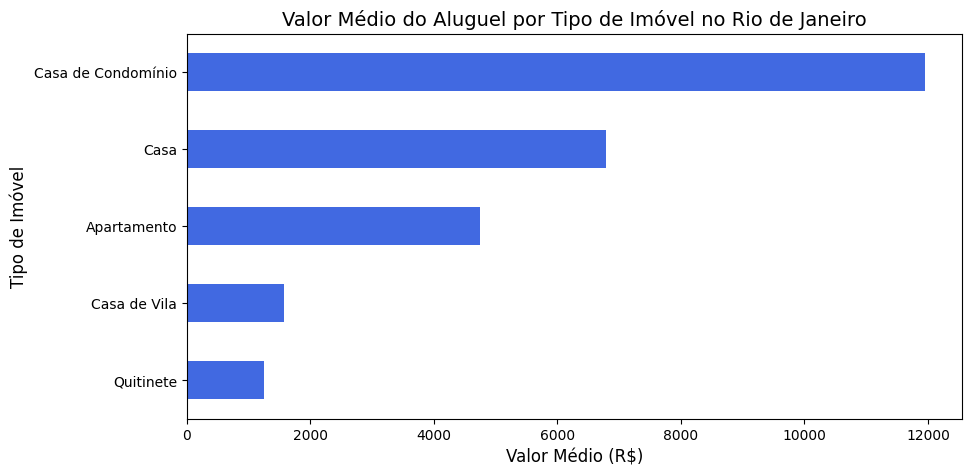

In [9]:
# 1. Agrupando os dados por 'Tipo' e calculando a média da coluna 'Valor'
media_por_tipo = dados_residencial.groupby('Tipo')['Valor'].mean().sort_values()

# 2. Configurando o visual do gráfico
plt.figure(figsize=(10, 5)) # Define o tamanho da imagem
media_por_tipo.plot(kind='barh', color='royalblue') # Cria um gráfico de barras horizontais (barh)

# 3. Adicionando os textos explicativos
plt.title('Valor Médio do Aluguel por Tipo de Imóvel no Rio de Janeiro', fontsize=14)
plt.xlabel('Valor Médio (R$)', fontsize=12)
plt.ylabel('Tipo de Imóvel', fontsize=12)

# 4. Exibindo o gráfico na tela
plt.show()

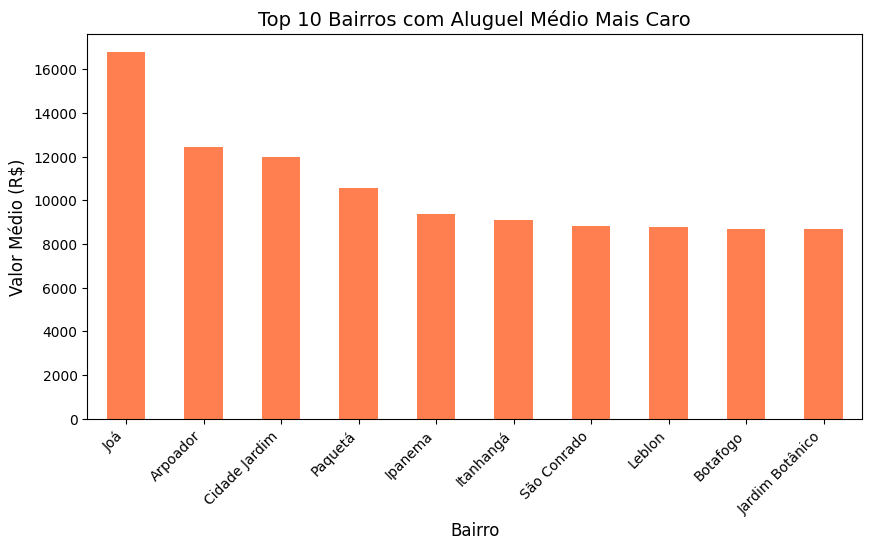

In [ ]:
# 1. Agrupando por bairro e pegando a média de valor, ordenando do maior para o menor
media_por_bairro = dados_residencial.groupby('Bairro')['Valor'].mean().sort_values(ascending=False)

# 2. Pegando apenas os 10 primeiros (head)
top_10_bairros = media_por_bairro.head(10)

# 3. Gerando o gráfico
plt.figure(figsize=(10, 5))
top_10_bairros.plot(kind='bar', color='coral')

# 4. Ajustes visuais
plt.title('Top 10 Bairros com Aluguel Médio Mais Caro', fontsize=14)
plt.xlabel('Bairro', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Valor Médio (R$)', fontsize=12)
plt.show()